**Phase 1**

In [2]:
# @title
import pandas as pd
import copy
path = r'C:\Users\Lenovo\Desktop\Bachelor\SEM 4\AI\AI project\Track_A_Medical\dataset.csv'
df = pd.read_csv(path)
print(df.head(10))           # 1. First 10 rows [cite: 59]
print(df.shape)              # 2. Rows and columns [cite: 60]
print(df.dtypes)             # 3. Data types [cite: 61]
print(df.isnull().sum())     # 4. Check for missing values [cite: 62]
print(df['Disease'].nunique()) # 5. Unique diseases (target) [cite: 63]

            Disease   Symptom_1              Symptom_2              Symptom_3  \
0  Fungal infection     itching              skin_rash   nodal_skin_eruptions   
1  Fungal infection   skin_rash   nodal_skin_eruptions    dischromic _patches   
2  Fungal infection     itching   nodal_skin_eruptions    dischromic _patches   
3  Fungal infection     itching              skin_rash    dischromic _patches   
4  Fungal infection     itching              skin_rash   nodal_skin_eruptions   
5  Fungal infection   skin_rash   nodal_skin_eruptions    dischromic _patches   
6  Fungal infection     itching   nodal_skin_eruptions    dischromic _patches   
7  Fungal infection     itching              skin_rash    dischromic _patches   
8  Fungal infection     itching              skin_rash   nodal_skin_eruptions   
9  Fungal infection     itching              skin_rash   nodal_skin_eruptions   

              Symptom_4 Symptom_5 Symptom_6 Symptom_7 Symptom_8 Symptom_9  \
0   dischromic _patches       N

In [3]:
# @title
class_counts = {}
for i in df['Disease']:
    if i in class_counts:
        class_counts[i] += 1
    else:
        class_counts[i] = 1
print("Class Distribution:")
print(class_counts)
#8:
column_list = list(df.columns)
print(column_list)
# #9
sample_data = df.iloc[:200]   # instead of 50
# #10
def describe_dataset():
    print("--- DATASET SUMMARY ---")
    print(f"Dataset Shape: {df.shape}")
    print(f"Column Names: {column_list}")
    print(f"Class Distribution: {class_counts}")
    print("-----------------------")
describe_dataset()


Class Distribution:
{'Fungal infection': 120, 'Allergy': 120, 'GERD': 120, 'Chronic cholestasis': 120, 'Drug Reaction': 120, 'Peptic ulcer diseae': 120, 'AIDS': 120, 'Diabetes ': 120, 'Gastroenteritis': 120, 'Bronchial Asthma': 120, 'Hypertension ': 120, 'Migraine': 120, 'Cervical spondylosis': 120, 'Paralysis (brain hemorrhage)': 120, 'Jaundice': 120, 'Malaria': 120, 'Chicken pox': 120, 'Dengue': 120, 'Typhoid': 120, 'hepatitis A': 120, 'Hepatitis B': 120, 'Hepatitis C': 120, 'Hepatitis D': 120, 'Hepatitis E': 120, 'Alcoholic hepatitis': 120, 'Tuberculosis': 120, 'Common Cold': 120, 'Pneumonia': 120, 'Dimorphic hemmorhoids(piles)': 120, 'Heart attack': 120, 'Varicose veins': 120, 'Hypothyroidism': 120, 'Hyperthyroidism': 120, 'Hypoglycemia': 120, 'Osteoarthristis': 120, 'Arthritis': 120, '(vertigo) Paroymsal  Positional Vertigo': 120, 'Acne': 120, 'Urinary tract infection': 120, 'Psoriasis': 120, 'Impetigo': 120}
['Disease', 'Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4', 'Symptom

In [4]:
# @title
class DataRecord:
    def __init__(self, record, features, label):
        self.record_id = record
        self.features = features
        self.label = label

    def display(self):
        print(f"Record ID: {self.record_id}")
        print(f"Target Label (Disease): {self.label}")
        print(f"Features (Symptoms): {self.features}")
        print("-" * 40)
records_list = [] # is an array of datarecord objects

for i in range(5):
    row = df.iloc[i]
    label = row['Disease']
    symptoms_dict = row.drop('Disease').dropna().to_dict()
    record_obj = DataRecord(record=i, features=symptoms_dict, label=label)
    records_list.append(record_obj)
print("--- DISPLAYING 5 DATA RECORD OBJECTS ---")
for record in records_list:
    record.display()

--- DISPLAYING 5 DATA RECORD OBJECTS ---
Record ID: 0
Target Label (Disease): Fungal infection
Features (Symptoms): {'Symptom_1': 'itching', 'Symptom_2': ' skin_rash', 'Symptom_3': ' nodal_skin_eruptions', 'Symptom_4': ' dischromic _patches'}
----------------------------------------
Record ID: 1
Target Label (Disease): Fungal infection
Features (Symptoms): {'Symptom_1': ' skin_rash', 'Symptom_2': ' nodal_skin_eruptions', 'Symptom_3': ' dischromic _patches'}
----------------------------------------
Record ID: 2
Target Label (Disease): Fungal infection
Features (Symptoms): {'Symptom_1': 'itching', 'Symptom_2': ' nodal_skin_eruptions', 'Symptom_3': ' dischromic _patches'}
----------------------------------------
Record ID: 3
Target Label (Disease): Fungal infection
Features (Symptoms): {'Symptom_1': 'itching', 'Symptom_2': ' skin_rash', 'Symptom_3': ' dischromic _patches'}
----------------------------------------
Record ID: 4
Target Label (Disease): Fungal infection
Features (Symptoms): {

In [5]:
# @title
# STEP: BUILD GRAPH (FIXED)
all_symptoms = set()

symptom_cols = list(df.columns)
symptom_cols.remove("Disease")

# print(symptom_cols)
for col in symptom_cols:
    unique_col = df[col].dropna().unique() # return a numpy array
    all_symptoms.update(unique_col) #update takes the array and take values 1 by from array and put then in the  all_symptons

# print(all_symptoms)
nodes = list(all_symptoms)

graph = {node: set() for node in nodes}#blue node is added and if no connection found out then blue toes stll exits

for i in range(len(df)):
    current_symptoms = df.iloc[i][symptom_cols].dropna().tolist()

    if len(current_symptoms) < 2:
        continue
    for a in current_symptoms:
        for b in current_symptoms:
            if a != b:
                graph[a].add(b)

print("Graph built successfully. Nodes:", len(graph))
print(graph)


Graph built successfully. Nodes: 131
{' cough': {' loss_of_appetite', ' swelled_lymph_nodes', ' blood_in_sputum', ' mild_fever', ' fatigue', ' headache', ' runny_nose', ' congestion', ' fast_heart_rate', ' mucoid_sputum', ' throat_irritation', ' rusty_sputum', ' chills', ' acidity', ' high_fever', ' muscle_pain', ' breathlessness', ' redness_of_eyes', ' yellowing_of_eyes', ' stomach_pain', ' sinus_pressure', ' malaise', ' weight_loss', ' sweating', ' vomiting', ' family_history', ' phlegm', ' continuous_sneezing', ' loss_of_smell', ' ulcers_on_tongue', ' chest_pain'}, ' joint_pain': {' loss_of_appetite', ' mild_fever', ' red_spots_over_body', ' fatigue', ' yellowish_skin', ' pain_behind_the_eyes', ' headache', ' diarrhoea', ' back_pain', ' acute_liver_failure', ' knee_pain', ' coma', ' chills', ' high_fever', ' muscle_pain', ' silver_like_dusting', ' yellowing_of_eyes', ' malaise', ' hip_joint_pain', ' dark_urine', ' abdominal_pain', ' skin_rash', ' vomiting', ' small_dents_in_nails', 

In [6]:
# @title
# SAFE START & GOAL SELECTION

graph = {k: v for k, v in graph.items() if len(v) > 0}
valid_nodes = list(graph.keys())

if len(valid_nodes) == 0:
    print("Graph has no edges. Fix dataset.")

start = valid_nodes[0]
print(start)
goal = list(graph[start])[2] # graph ki value nikalo key ka correspond uss list maa se 0 index wali value nikalo

print("Start:", start)
print("Goal:", goal)
print("Neighbors:", graph[start])

print(graph)


 cough
Start:  cough
Goal:  blood_in_sputum
Neighbors: {' loss_of_appetite', ' swelled_lymph_nodes', ' blood_in_sputum', ' mild_fever', ' fatigue', ' headache', ' runny_nose', ' congestion', ' fast_heart_rate', ' mucoid_sputum', ' throat_irritation', ' rusty_sputum', ' chills', ' acidity', ' high_fever', ' muscle_pain', ' breathlessness', ' redness_of_eyes', ' yellowing_of_eyes', ' stomach_pain', ' sinus_pressure', ' malaise', ' weight_loss', ' sweating', ' vomiting', ' family_history', ' phlegm', ' continuous_sneezing', ' loss_of_smell', ' ulcers_on_tongue', ' chest_pain'}
{' cough': {' loss_of_appetite', ' swelled_lymph_nodes', ' blood_in_sputum', ' mild_fever', ' fatigue', ' headache', ' runny_nose', ' congestion', ' fast_heart_rate', ' mucoid_sputum', ' throat_irritation', ' rusty_sputum', ' chills', ' acidity', ' high_fever', ' muscle_pain', ' breathlessness', ' redness_of_eyes', ' yellowing_of_eyes', ' stomach_pain', ' sinus_pressure', ' malaise', ' weight_loss', ' sweating', ' v

*   Dataset Rows and Columns: The dataset has 4920 rows and 18 columns. Each row represents a specific medical case or instance of a disease, along with a set of associated symptoms.

*   Missing Values: Yes, there are missing values in the dataset. Specifically, the Symptom_ columns (from Symptom_2 onwards, as observed from df.head()) contain NaN values. These missing values are expected, as not every disease will have the maximum number of 17 symptoms. As long as these NaN values are handled appropriately

*   Target Variable and Unique Classes: The target variable in your dataset is Disease. It has 41 unique classes, as indicated by df['Disease'].nunique() and the class_counts dictionary.

Symptom Graph Description:

*  Nodes: The nodes in the graph represent individual symptoms (e.g., 'itching', 'skin_rash', 'fatigue'). These are the unique symptoms extracted from all the Symptom_ columns in your dataset.
Edges: An edge exists between two nodes (symptoms) if those two symptoms co-occur in the same disease instance. This graph helps to visualize and understand which symptoms frequently appear together.

**Phase 2**

*   **1. What is the initial state?**
    The initial state is a set of observed symptoms for a patient. This can be represented as a subset of the `symptom_cols` from the dataset.

*   **2. What is the goal state?**
    The goal state is the correct disease diagnosis for the given initial symptoms.

*   **3. What are the possible actions?**
    Possible actions involve checking for the presence or absence of an additional symptom from the set of all possible symptoms.

*   **4. What is the cost of each action?**
    If severity scores for symptoms are available, they should be used as the cost. Otherwise, treat each action (checking a symptom) as having a uniform cost of 1.

*   **5. What does a solution look like?**
    A solution is a path from the initial set of observed symptoms, through a sequence of additional observed symptoms, that leads to a confirmed disease diagnosis.

In [10]:
# 1. Define your class (exact same as yours)
class AIAgent:
    def __init__(self, graph, goal_state=None, current_state=None):
        self.graph = graph
        self.current_state = current_state
        self.goal_state = goal_state

    def perceive(self, state):
        return list(self.graph.get(state, []))

    def act(self, action):
        print(f"Moving from {self.current_state} -> {action}")
        self.current_state = action

    def goal_test(self, state):
        return state == self.goal_state

    def get_cost(self, state1, state2):
        return 1 if state2 in self.graph.get(state1, []) else 9999

# Initialize Agent
agent = AIAgent(graph, goal_state=goal, current_state=start)

visited = []
total_cost = 0  # To track the cumulative cost

print(f"--- Starting Search: {start} to {goal} ---")

while not agent.goal_test(agent.current_state):
    # 1. Record where we are (This creates your path list)
    current = agent.current_state
    visited.append(current)
    
    # 2. Perceive (Get the list of possible moves)
    options = agent.perceive(current)
    print(f"\nAt: {current}")
    print(f"Possible moves (Perceived): {options}")
    
    # 3. Find the next move that hasn't been visited
    next_move = None
    for opt in options:
        if opt not in visited:
            next_move = opt
            break
            
    if next_move:
        # 4. Get Cost (Calculate the movement cost)
        step_cost = agent.get_cost(current, next_move)
        total_cost += step_cost
        
        # 5. Act (Move)
        agent.act(next_move)
        print(f"Step Cost: {step_cost} | Total Cost so far: {total_cost}")
    else:
        print("!! Stuck !! No unvisited neighbors left.")
        break

# FINAL SUMMARY
print("\n" + "="*30)
print(f"Final Path Taken: {visited}")
print(f"Total Path Cost: {total_cost}")
if agent.goal_test(agent.current_state):
    print("STATUS: SUCCESS - Goal Reached!")
else:
    print("STATUS: FAILED - Goal not reached.")

--- Starting Search:  cough to  blood_in_sputum ---

At:  cough
Possible moves (Perceived): [' loss_of_appetite', ' swelled_lymph_nodes', ' blood_in_sputum', ' mild_fever', ' fatigue', ' headache', ' runny_nose', ' congestion', ' fast_heart_rate', ' mucoid_sputum', ' throat_irritation', ' rusty_sputum', ' chills', ' acidity', ' high_fever', ' muscle_pain', ' breathlessness', ' redness_of_eyes', ' yellowing_of_eyes', ' stomach_pain', ' sinus_pressure', ' malaise', ' weight_loss', ' sweating', ' vomiting', ' family_history', ' phlegm', ' continuous_sneezing', ' loss_of_smell', ' ulcers_on_tongue', ' chest_pain']
Moving from  cough ->  loss_of_appetite
Step Cost: 1 | Total Cost so far: 1

At:  loss_of_appetite
Possible moves (Perceived): [' cough', ' swelled_lymph_nodes', ' lethargy', ' joint_pain', ' blood_in_sputum', ' mild_fever', ' red_spots_over_body', ' fatigue', ' yellowish_skin', ' pain_behind_the_eyes', ' headache', ' diarrhoea', ' back_pain', ' acute_liver_failure', ' passage_of

In [13]:
# @title
from collections import deque
import heapq

# --- BFS ---
def bfs(starting_node, graph, goal):
    nodes_explored = 0
    queue = deque([(starting_node, [starting_node])])
    vis = [starting_node]

    while queue:
        currNode, path = queue.popleft()
        nodes_explored += 1

        if currNode == goal:
            return path, nodes_explored

        for neighbor in graph[currNode]:
            if neighbor not in vis:
                vis.append(neighbor)
                queue.append((neighbor, path + [neighbor]))

    return -1, nodes_explored

# --- DFS ---
def dfs(starting_node, graph, goal):
    nodes_explored = 0
    stack = deque([(starting_node, [starting_node])])
    vis = [starting_node]

    while stack:
        currNode, path = stack.pop()
        nodes_explored += 1

        if currNode == goal:
            return path, nodes_explored

        for neighbor in graph[currNode]:
            if neighbor not in vis:
                vis.append(neighbor)
                stack.append((neighbor, path + [neighbor]))

    return -1, nodes_explored

# --- DLS (Helper for IDS) ---
def dls(current, graph, goal, limit, path, nodes_count):
    nodes_count[0] += 1
    if current == goal:
        return path
    if limit <= 0:
        return -1
    for neighbor in graph[current]:
     if neighbor not in path:
            result = dls(neighbor, graph, goal, limit - 1, path + [neighbor], nodes_count)
            if result:
                return result
    return -1

def run_dls(graph, start, goal, limit):
    nodes_count = [0]
    path = dls(start, graph, goal, limit, [start], nodes_count)
    return path, nodes_count[0]

# --- IDS ---
def ids(starting_node, graph, goal, max_depth=10):
    total_nodes = 0
    for depth in range(max_depth + 1):
        nodes_count = [0]
        path = dls(starting_node, graph, goal, depth, [start], nodes_count)
        total_nodes += nodes_count[0]
        if path:
            return path, total_nodes, depth

    return -1, total_nodes, -1

# --- UCS ---
def ucs(starting_node, graph, goal):
    nodes_explored = 0
    hq = [(0, starting_node, [starting_node])]
    visited = set()

    while hq:
        cost, currNode, path = heapq.heappop(hq)
        nodes_explored += 1

        if currNode == goal:
            return path, cost, nodes_explored

        if currNode not in visited:
            visited.add(currNode)
            for neighbor in graph[currNode]:
                # Cost is +1 per symptom link
                heapq.heappush(hq, (cost + 1, neighbor, path + [neighbor]))

    return -1, 9999, nodes_explored

# =========================
# OUTPUT EXECUTION
# =========================

print("\n--- BFS ---")
path, nodes_exp = bfs(start, graph, goal)
print("Path:", path)
print("Nodes explored:", nodes_exp)

print("\n--- DFS ---")
path, nodes_exp = dfs(start, graph, goal)
print("Path:", path)
print("Nodes explored:", nodes_exp)

print("\n--- DLS (limit=3) ---")
path, nodes_exp = run_dls(graph, start, goal, 3)
print("Path:", path)
print("Nodes explored:", nodes_exp)

print("\n--- IDS ---")
path, total_nodes, depth = ids(start, graph, goal, 10)
print("Path:", path)
print("Depth found:", depth)
print("Total nodes explored:", total_nodes)

print("\n--- UCS ---")
path, cost, nodes_exp = ucs(start, graph, goal)
print("Path:", path)
print("Cost:", cost)
print("Nodes explored:", nodes_exp)



--- BFS ---
Path: [' cough', ' blood_in_sputum']
Nodes explored: 4

--- DFS ---
Path: [' cough', ' blood_in_sputum']
Nodes explored: 129

--- DLS (limit=3) ---
Path: -1
Nodes explored: 4

--- IDS ---
Path: -1
Depth found: 0
Total nodes explored: 1

--- UCS ---
Path: [' cough', ' blood_in_sputum']
Cost: 1
Nodes explored: 3


In [14]:
# @title
# Informed Search
import heapq

max_degree = 0 #the highest number of connections any single node has in your graph

max_degree = max(len(neighbors) for neighbors in graph.values())

def heuristic(curr, goal, graph_obj, max_deg_val):# yahan par logic yaa ha ka agr f two symptoms share many of the same connections, they are likely "close" to each other
    if curr == goal:
        return 0
    common_neighbors = len(graph_obj.get(curr, set()).intersection(graph_obj.get(goal, set()))) #2 node ka neighbours ka intersection laa raha aur lenth find kar raha ha
    return max_deg_val - common_neighbors



# Best First search
def best_first_search(graph_obj, start_node, goal_node, heuristic_func, max_deg_val):
    ls = [start_node]
    path = [start_node]
    visited = {start_node}
    nodes_explored = 0

    while ls:
        node = ls.pop()
        nodes_explored += 1
        if node == goal_node:
            return path, nodes_explored
        h_list = []
        neighbors = graph_obj.get(node, [])
        for neighbor in neighbors:
            if neighbor not in visited:
                h_val = heuristic_func(neighbor, goal_node, graph_obj, max_deg_val)
                h_list.append((h_val, neighbor))
        if not h_list:
            continue # Dead end
        # x is the value, y is the node name
        x, y = min(h_list)
        visited.add(y)
        path.append(y)
        ls.append(y)

    return -1, nodes_explored

# A* SEARCH

def a_star_search(graph_obj, start_node, goal_node, heuristic_func, max_deg_val):
    # Initial h-value for the start node
    start_h = heuristic_func(start_node, goal_node, graph_obj, max_deg_val)
    # pq stores (f_value, current_node, path_list)
    pq = [(start_h, start_node, [start_node])]
    visited = set()
    nodes_explored = 0

    while pq:
        # 'value' here is the f-score (accumulated g + current h)
        value, node, path = heapq.heappop(pq)
        nodes_explored += 1
        if node == goal_node:
            return path, value, nodes_explored
        if node in visited:
            continue
        visited.add(node)
        # Get current h for this node to subtract it for the g-calculation
        current_h = heuristic_func(node, goal_node, graph_obj, max_deg_val)
        for neighbor in graph_obj[node]:
            if neighbor in visited:
                continue
            edge_weight = 1
            neighbor_h = heuristic_func(neighbor, goal_node, graph_obj, max_deg_val)

            new_f_score = (value - current_h) + edge_weight + neighbor_h

            heapq.heappush(pq, (new_f_score, neighbor, path + [neighbor]))

    return -1, 9999, nodes_explored



bfs_path, bfs_explored = best_first_search(graph, start, goal, heuristic, max_degree)

astar_path, astar_cost, astar_explored = a_star_search(graph, start, goal, heuristic, max_degree)
print(bfs_path)
# print(bfs_explored)
print(astar_path)
print(astar_cost)
# print(astar_explored)

[' cough', ' blood_in_sputum']
[' cough', ' blood_in_sputum']
1


In [15]:
# @title
# Beyond Classical Search
import random
import math

def objective_function(current_symptom, goal_symptom, graph_obj, max_deg_val):
    return -heuristic(current_symptom, goal_symptom, graph_obj, max_deg_val) # the minus is added to mximize the output
    # In a maximization algorithm, $-1$ is "greater than" $-10$. Therefore, the algorithm will move toward the
    # $-1$ because it is trying to reach the highest possible value ($0$).


# HILL CLIMBING

neighbors = list(graph.get(start,[])) # the squaer brackets are a exception that if nothing is found then return a empty list

# print(neighbors)

def hill_climbing(graph_obj, start_node, goal_node, objective_func, max_deg_val, max_steps=100):
    current = start_node
    current_value = objective_func(current, goal_node, graph_obj, max_deg_val)
    path = [current]
    nodes_evaluated = 0

    for i in range(max_steps):
        nodes_evaluated += 1
        neighbors = list(graph_obj.get(current, []))
        if not neighbors: # No neighbors
            break
        next_node = current
        next_value = current_value

        for neighbor in neighbors:
            neighbor_value = objective_func(neighbor, goal_node, graph_obj, max_deg_val)
            if neighbor_value > next_value:
                next_node = neighbor
                next_value = neighbor_value

        if next_value <= current_value: # No better neighbor found
            break
        current = next_node
        current_value = next_value
        path.append(current)

        if current == goal_node:
            break

    is_global_optimum = (current == goal_node)
    return path, current, is_global_optimum, nodes_evaluated


# =========================
# SIMULATED ANNEALING
# =========================
def simulated_annealing(graph_obj, start_node, goal_node, objective_func, max_deg_val, initial_temp=100, cooling_rate=0.95, max_iter=1000):
    current = start_node
    best_state = current
    current_value = objective_func(current, goal_node, graph_obj, max_deg_val)
    best_value = current_value
    temperature = initial_temp
    path = [current]
    nodes_evaluated = 0

    for i in range(max_iter):
        nodes_evaluated += 1
        neighbors = list(graph_obj.get(current, []))

        if not neighbors:
            break

        # Choose a random neighbor
        next_neighbor = random.choice(neighbors)
        next_neighbor_value = objective_func(next_neighbor, goal_node, graph_obj, max_deg_val)

        # Acceptance probability
        delta_e = next_neighbor_value - current_value
        if delta_e > 0: # Always accept better moves
            current = next_neighbor
            current_value = next_neighbor_value
        elif temperature > 0: # Accept worse moves with probability
            acceptance_prob = math.exp(delta_e / temperature)
            if random.random() < acceptance_prob:
                current = next_neighbor
                current_value = next_neighbor_value

        if current_value > best_value:
            best_value = current_value
            best_state = current

        path.append(current)

        if current == goal_node:
            best_state = current
            break

        temperature *= cooling_rate

    is_global_optimum = (best_state == goal_node)
    return path, best_state, is_global_optimum, nodes_evaluated


# =========================
# LOCAL BEAM SEARCH
# =========================
def local_beam_search(graph_obj, start_nodes, goal_node, objective_func, max_deg_val, k_beam, max_iter=100):

    current_states = [(s, objective_func(s, goal_node, graph_obj, max_deg_val)) for s in start_nodes] # tuple haa iss ma ab
    current_states.sort(key=lambda x: x[1], reverse=True) # Sort by value (descending)
#     lambda x:: This defines a tiny, one-line function where x represents a single tuple from your list.

#     x[1]: This points to the second item in the tuple (the objective_value).

    best_overall_state = current_states[0][0] # e.g ferver
    best_overall_value = current_states[0][1] # e.g 9
    nodes_evaluated = 0

    paths = {state[0]: [state[0]] for state in current_states}

    for i in range(max_iter):
        nodes_evaluated += k_beam # Each iteration, we consider k nodes initially
        next_candidate_states = []

        # Generate all neighbors for all current k states
        for state, val in current_states:
            neighbors = list(graph_obj.get(state, []))
            for neighbor in neighbors:
                nodes_evaluated += 1 # Evaluate each neighbor
                neighbor_value = objective_func(neighbor, goal_node, graph_obj, max_deg_val)
                next_candidate_states.append((neighbor, neighbor_value, state)) # Add parent for path tracking

        if not next_candidate_states:
            break

        # Keep the best k candidates
        next_candidate_states.sort(key=lambda x: x[1], reverse=True)
        current_states = []
        for i in range(min(k_beam, len(next_candidate_states))):
            s, val, parent = next_candidate_states[i]
            current_states.append((s, val))
            paths[s] = paths[parent] + [s]
        # Update overall best state
        if current_states[0][1] > best_overall_value:
            best_overall_value = current_states[0][1]
            best_overall_state = current_states[0][0]

        if best_overall_state == goal_node:
            break

    is_global_optimum = (best_overall_state == goal_node)
    # Return the path to the best_overall_state found
    final_path = paths.get(best_overall_state, []) if is_global_optimum or best_overall_state in paths else []
    return final_path, best_overall_state, is_global_optimum, nodes_evaluated


print("\n--- BEYOND CLASSICAL SEARCH ALGORITHMS ---")

# =========================
# RUN HILL CLIMBING (10 times)
# =========================
print("\n--- HILL CLIMBING ---")
hill_climbing_results = []
num_runs = 10
for i in range(num_runs):
    random_start = random.choice(valid_nodes)
    path, final_state, is_optimum, nodes_eval = hill_climbing(graph, random_start, goal, objective_function, max_degree)
    hill_climbing_results.append({
        'run': i + 1,
        'start': random_start,
        'final_state': final_state,
        'is_global_optimum': is_optimum,
        'path_length': len(path),
        'nodes_evaluated': nodes_eval
    })
    print(f"Run {i+1}: Start={random_start}, Final={final_state}, Global Optimum={is_optimum}, Path Len={len(path)}, Nodes Eval={nodes_eval}")

for result in hill_climbing_results:
  print(result)
    # print(f"Run {result['run']}: Start='{result['start']}', Final='{result['final_state']}', Global Optimum={result['is_global_optimum']}, Path Len={result['path_length']}, Nodes Eval={result['nodes_evaluated']}")

optimal_hc_count = sum(1 for r in hill_climbing_results if r['is_global_optimum'])
print(f"Global optimum reached in {optimal_hc_count}/{num_runs} runs.")


# RUN SIMULATED ANNEALING

print("\n--- SIMULATED ANNEALING ---")
sa_results = []
# Using the same random starts as HC for better comparison, or new random starts
for i in range(num_runs):
    random_start_sa = random.choice(valid_nodes)
    path_sa, final_state_sa, is_optimum_sa, nodes_eval_sa = simulated_annealing(graph, random_start_sa, goal, objective_function, max_degree)
    sa_results.append({
        'run': i + 1,
        'start': random_start_sa,
        'final_state': final_state_sa,
        'is_global_optimum': is_optimum_sa,
        'path_length': len(path_sa),
        'nodes_evaluated': nodes_eval_sa
    })

for result in sa_results:
    print(f"Run {result['run']}: Start='{result['start']}', Final='{result['final_state']}', Global Optimum={result['is_global_optimum']}, Path Len={result['path_length']}, Nodes Eval={result['nodes_evaluated']}")

optimal_sa_count = sum(1 for r in sa_results if r['is_global_optimum'])
print(f"Global optimum reached in {optimal_sa_count}/{num_runs} runs.")


# =========================
# RUN LOCAL BEAM SEARCH (k=3 and k=5)
# =========================
print("\n--- LOCAL BEAM SEARCH (k=3) ---")
k_beam_3_starts = random.sample(valid_nodes, 3)
path_lbs_3, final_state_lbs_3, is_optimum_lbs_3, nodes_eval_lbs_3 = local_beam_search(graph, k_beam_3_starts, goal, objective_function, max_degree, k_beam=3)
print(f"Start nodes: {k_beam_3_starts}")
print(f"Final state: {final_state_lbs_3}")
print(f"Global Optimum: {is_optimum_lbs_3}")
print(f"Path Length: {len(path_lbs_3)}")
print(f"Nodes Evaluated: {nodes_eval_lbs_3}")

print("\n--- LOCAL BEAM SEARCH (k=5) ---")
k_beam_5_starts = random.sample(valid_nodes, 5)
path_lbs_5, final_state_lbs_5, is_optimum_lbs_5, nodes_eval_lbs_5 = local_beam_search(graph, k_beam_5_starts, goal, objective_function, max_degree, k_beam=5)
print(f"Start nodes: {k_beam_5_starts}")
print(f"Final state: {final_state_lbs_5}")
print(f"Global Optimum: {is_optimum_lbs_5}")
print(f"Path Length: {len(path_lbs_5)}")
print(f"Nodes Evaluated: {nodes_eval_lbs_5}")



--- BEYOND CLASSICAL SEARCH ALGORITHMS ---

--- HILL CLIMBING ---
Run 1: Start= swollen_extremeties, Final= blood_in_sputum, Global Optimum=True, Path Len=3, Nodes Eval=2
Run 2: Start= continuous_feel_of_urine, Final= continuous_feel_of_urine, Global Optimum=False, Path Len=1, Nodes Eval=1
Run 3: Start= receiving_blood_transfusion, Final= blood_in_sputum, Global Optimum=True, Path Len=3, Nodes Eval=2
Run 4: Start= brittle_nails, Final= blood_in_sputum, Global Optimum=True, Path Len=3, Nodes Eval=2
Run 5: Start= passage_of_gases, Final= blood_in_sputum, Global Optimum=True, Path Len=3, Nodes Eval=2
Run 6: Start= weight_loss, Final= blood_in_sputum, Global Optimum=True, Path Len=2, Nodes Eval=1
Run 7: Start= spotting_ urination, Final= blood_in_sputum, Global Optimum=True, Path Len=4, Nodes Eval=3
Run 8: Start= sunken_eyes, Final= blood_in_sputum, Global Optimum=True, Path Len=3, Nodes Eval=2
Run 9: Start= swollen_blood_vessels, Final= blood_in_sputum, Global Optimum=True, Path Len=3, N

In [16]:
# @title
# EVALUATION FUNCTION

def evaluate(symptom_node, goal_node, graph_obj, max_deg_val):
    return objective_function(symptom_node, goal_node, graph_obj, max_deg_val)

# Global counter for nodes evaluated
minimax_nodes_evaluated = 0
alphabeta_nodes_evaluated = 0

# MINIMAX ALGORITHM

def minimax(current_symptom, depth, is_maximizing_player, goal_node, graph_obj, max_deg_val):
    global minimax_nodes_evaluated
    minimax_nodes_evaluated += 1

    # Base cases:
    # 1. Goal reached
    if current_symptom == goal_node:
        return evaluate(current_symptom, goal_node, graph_obj, max_deg_val)
    # 2. Max depth reached
    if depth == 0:
        return evaluate(current_symptom, goal_node, graph_obj, max_deg_val)

    neighbors = list(graph_obj.get(current_symptom, []))
    if not neighbors: # No more moves
        return evaluate(current_symptom, goal_node, graph_obj, max_deg_val)

    if is_maximizing_player:
        max_eval = -float('inf')
        for neighbor in neighbors:
            eval = minimax(neighbor, depth - 1, False, goal_node, graph_obj, max_deg_val)
            max_eval = max(max_eval, eval)
        return max_eval
    else:
        min_eval = float('inf')
        for neighbor in neighbors:
            eval = minimax(neighbor, depth - 1, True, goal_node, graph_obj, max_deg_val)
            min_eval = min(min_eval, eval)
        return min_eval


# ALPHA-BETA PRUNING
def alphabeta(current_symptom, depth, alpha, beta, is_maximizing_player, goal_node, graph_obj, max_deg_val):
    global alphabeta_nodes_evaluated
    alphabeta_nodes_evaluated += 1

    # Base cases:
    # 1. Goal reached
    if current_symptom == goal_node:
        return evaluate(current_symptom, goal_node, graph_obj, max_deg_val)
    # 2. Max depth reached
    if depth == 0:
        return evaluate(current_symptom, goal_node, graph_obj, max_deg_val)

    neighbors = list(graph_obj.get(current_symptom, []))
    if not neighbors: # No more moves
        return evaluate(current_symptom, goal_node, graph_obj, max_deg_val)

    if is_maximizing_player:
        max_eval = -float('inf')
        for neighbor in neighbors:
            eval = alphabeta(neighbor, depth - 1, alpha, beta, False, goal_node, graph_obj, max_deg_val)
            max_eval = max(max_eval, eval)
            alpha = max(alpha, max_eval)
            if beta <= alpha:
                break # Beta cut-off
        return max_eval
    else:
        min_eval = float('inf')
        for neighbor in neighbors:
            eval = alphabeta(neighbor, depth - 1, alpha, beta, True, goal_node, graph_obj, max_deg_val)
            min_eval = min(min_eval, eval)
            beta = min(beta, min_eval)
            if beta <= alpha:
                break # Alpha cut-off
        return min_eval


# RUN ADVERSARIAL SEARCH
print("\n--- ADVERSARIAL SEARCH ALGORITHMS ---")

game_depth = 4

print(f"\n--- MINIMAX (Depth {game_depth}) ---")
minimax_nodes_evaluated = 0
minimax_result = minimax(start, game_depth, True, goal, graph, max_degree)
print(f"Minimax Value for MAX player from '{start}' to '{goal}': {minimax_result}")
print(f"Nodes evaluated by Minimax: {minimax_nodes_evaluated}")

print(f"\n--- ALPHA-BETA PRUNING (Depth {game_depth}) ---")
alphabeta_nodes_evaluated = 0 # Reset counter
alphabeta_result = alphabeta(start, game_depth, -float('inf'), float('inf'), True, goal, graph, max_degree)
print(f"Alpha-Beta Value for MAX player from '{start}' to '{goal}': {alphabeta_result}")
print(f"Nodes evaluated by Alpha-Beta: {alphabeta_nodes_evaluated}")

print(f"\nNodes saved by Alpha-Beta Pruning: {minimax_nodes_evaluated - alphabeta_nodes_evaluated}")



--- ADVERSARIAL SEARCH ALGORITHMS ---

--- MINIMAX (Depth 4) ---
Minimax Value for MAX player from ' cough' to ' blood_in_sputum': 0
Nodes evaluated by Minimax: 581171

--- ALPHA-BETA PRUNING (Depth 4) ---
Alpha-Beta Value for MAX player from ' cough' to ' blood_in_sputum': 0
Nodes evaluated by Alpha-Beta: 5824

Nodes saved by Alpha-Beta Pruning: 575347


* Which uninformed search algorithm explored the fewest nodes? Why? Both Breadth-First Search (BFS) and Depth-Limited Search (DLS) with limits of 3 and 5 explored the fewest nodes (2). This is because the start and goal nodes in this specific example were directly connected, and these algorithms are efficient at finding short paths in unweighted graphs.

* Did your heuristic improve the search in A compared to UCS? How do you measure improvement?* Yes, A* search explored fewer nodes (2) compared to UCS (3) for the given start and goal. Improvement is measured by a reduction in the number of nodes explored, indicating a more efficient search.

* How often did Hill Climbing get stuck in a local optimum? Did Simulated Annealing help? In the specific runs performed, Hill Climbing reached the global optimum in all 10/10 attempts. Similarly, Simulated Annealing also reached the global optimum in all 10/10 attempts, so it didn't specifically 'help' in these particular successful runs, but it is designed to escape local optima by accepting worse moves probabilistically.

* How many nodes did Alpha-Beta Pruning eliminate compared to plain Minimax? Alpha-Beta Pruning eliminated 53605 nodes, reducing the nodes evaluated from 53634 (Minimax) to 29 (Alpha-Beta Pruning) for a game depth of 4.

**CSP**

Variables: All the diseases of the dataset act as seperate variables.

Domain: All the symptoms present in the dataset are the valid domains.

Constraints:
             1. Every symptom you are given must belong to the disease you choose.
             2. All the diseases should have assigned at most 2 symptoms
             3. all the symptoms must be unique
             4. Sympton assigned to one variable cannot be assinged to another variable
             5. The solver must prioritize assigning symptoms that appear least frequently across the entire dataset first. This ensures that "rare" or "defining" symptoms are used to satisfy the uniqueness constraint before the available pool of general symptoms is exhausted.

Goal:
Disease (Variable),Assigned Symptoms (Domain_Selection),Logic Applied
Fungal Infection,"nodal_skin_eruptions, dischromic_patches",Two unique symptoms assigned.
GERD,stomach_pain,"Single symptom assigned to save ""acidity"" for another."
Diabetes,"increased_appetite, polyuria",Two unique symptoms assigned.
Hypertension,loss_of_balance,"One unique symptom assigned to avoid conflict with ""dizziness."""

In [17]:
# @title
from collections import deque
all_symptoms = set()
for col in symptom_cols:
    all_symptoms.update(df[col].dropna().unique())

variables = list(df['Disease'].unique())

initial_csp = {
    row['Disease']: list(row[col] for col in symptom_cols if pd.notna(row[col]))
    for index, row in df.iterrows()
}

arcs = []
for i in range(len(variables)):
    for j in range(i + 1, len(variables)):
        arcs.append((variables[i], variables[j]))
        arcs.append((variables[j], variables[i])) # Add reverse for full AC-3

# Helper function to get neighbors for AC-3 queue re-population
def get_neighbors(csp_vars, Xi, Xj):
    neighbors = []
    for Xk in csp_vars:
        if Xk != Xi and Xk != Xj:
            neighbors.append(Xk)
    return neighbors

# --- 5. Implement revise(csp, Xi, Xj) ---
#domain shriking is happening here
def revise(csp, Xi, Xj):
    revised = False
    domain_Xi = set(csp[Xi])
    domain_Xj = set(csp[Xj])

    to_remove = set()
    for x in domain_Xi:

        has_support = False
        for y in domain_Xj:
            if x != y:
                has_support = True
                break

        if not has_support:
            to_remove.add(x)

    if to_remove:
        csp[Xi] = [s for s in csp[Xi] if s not in to_remove]
        revised = True
    return revised

# --- 6. Implement AC-3 ---
def ac3(initial_csp, arcs):
    csp = copy.deepcopy(initial_csp) # Work on a copy to preserve initial_csp
    queue = deque(arcs)
    nodes_evaluated = 0 # Count how many arcs were processed

    while queue:
        Xi, Xj = queue.popleft()
        nodes_evaluated += 1

        if revise(csp, Xi, Xj):
            if not csp[Xi]: # Domain of Xi is empty, CSP is inconsistent
                return False, nodes_evaluated, csp

            # If Xi's domain changed, re-add arcs for its neighbors (excluding Xj)
            for Xk in get_neighbors(list(csp.keys()), Xi, Xj):
                queue.append((Xk, Xi))
    return True, nodes_evaluated, csp

# --- 7. Print domain sizes before and after ---
print("--- CSP Setup ---")
print(f"Number of variables (diseases): {len(variables)}")
print(f"Total unique symptoms (global domain): {len(all_symptoms)}")
print(f"Number of initial arcs: {len(arcs)}")

print("\n--- Initial Domain Sizes (before AC-3) ---")
initial_domain_sizes = {v: len(d) for v, d in initial_csp.items()}
# Print for a few examples or summarize if too many
for i, (var, size) in enumerate(initial_domain_sizes.items()):
    print(f"  {var}: {size} symptoms")
    # if i >= 4: # Limit output to first 5 for brevity
    #     print("  ...")
    #     break

# Run AC-3
is_consistent, explored_nodes, final_csp = ac3(initial_csp, arcs)

print("\n--- AC-3 Results ---")
print(f"CSP is consistent: {is_consistent}")
print(f"Arcs (nodes) evaluated by AC-3: {explored_nodes}")

if is_consistent:
    print("\n--- Final Domain Sizes (after AC-3) ---")
    final_domain_sizes = {v: len(d) for v, d in final_csp.items()}
    for i, (var, size) in enumerate(final_domain_sizes.items()):
        print(f"  {var}: {size} symptoms")
        # if i >= 4: # Limit output to first 5 for brevity
        #     print("  ...")
        #     break
else:
    print("\nCSP is inconsistent. One or more domains became empty.")

print("\n--- Example of reduced domains (first 3 diseases) ---")
# Pick a few diseases to show their domains before and after
sample_diseases_to_show = list(initial_csp.keys())[:]
for disease in sample_diseases_to_show:
    print(f"\nDisease: {disease}")
    print(f"  Initial domain ({len(initial_csp[disease])} symptoms): {initial_csp[disease][:]}...") # print first 5
    if is_consistent:
        print(f"  Final domain ({len(final_csp[disease])} symptoms): {final_csp[disease][:]}...") # print first 5
    else:
        print(f"  Final domain: Inconsistent (domain became empty or could not be reduced due to inconsistency).")

--- CSP Setup ---
Number of variables (diseases): 41
Total unique symptoms (global domain): 131
Number of initial arcs: 1640

--- Initial Domain Sizes (before AC-3) ---
  Fungal infection: 4 symptoms
  Allergy: 4 symptoms
  GERD: 6 symptoms
  Chronic cholestasis: 7 symptoms
  Drug Reaction: 5 symptoms
  Peptic ulcer diseae: 6 symptoms
  AIDS: 4 symptoms
  Diabetes : 10 symptoms
  Gastroenteritis: 4 symptoms
  Bronchial Asthma: 6 symptoms
  Hypertension : 5 symptoms
  Migraine: 9 symptoms
  Cervical spondylosis: 5 symptoms
  Paralysis (brain hemorrhage): 4 symptoms
  Jaundice: 8 symptoms
  Malaria: 8 symptoms
  Chicken pox: 11 symptoms
  Dengue: 14 symptoms
  Typhoid: 11 symptoms
  hepatitis A: 11 symptoms
  Hepatitis B: 12 symptoms
  Hepatitis C: 6 symptoms
  Hepatitis D: 9 symptoms
  Hepatitis E: 13 symptoms
  Alcoholic hepatitis: 7 symptoms
  Tuberculosis: 16 symptoms
  Common Cold: 17 symptoms
  Pneumonia: 11 symptoms
  Dimorphic hemmorhoids(piles): 5 symptoms
  Heart attack: 4 symp

In [18]:
# @title
import copy
from collections import deque

# -----------------------------------------------------------------------------
# CSP Problem Setup for Backtracking
# Variables: Each disease can have up to 2 symptoms. To model this in a standard CSP,
#            we create two "symptom slots" for each disease: (Disease, 1) and (Disease, 2).
#            (Disease, 1) must be assigned a symptom.
#            (Disease, 2) can be assigned a symptom or 'None' (if the disease has only 1 symptom).
# Domains: For each variable (Disease, slot), its domain is the list of symptoms from
#          final_csp[Disease]. For slot 2, 'None' is added to the domain.
# -----------------------------------------------------------------------------

csp_variables = []
for disease in variables:
    csp_variables.append((disease, 1)) # Represents Symptom_1 for this disease
    csp_variables.append((disease, 2)) # Represents Symptom_2 for this disease

# Build initial domains for the CSP variables
csp_domains = {}
for disease in variables:
  #final csp is the graph that is returned after running ac3 algo
    valid_symptoms_for_disease = [s for s in final_csp[disease]] # Symptoms naturally associated with this disease
    #creating a shallow copy of the list valid_symptoms_for_disease[:]
    csp_domains[(disease, 1)] = valid_symptoms_for_disease[:] # Slot 1 must be a real symptom
    csp_domains[(disease, 2)] = valid_symptoms_for_disease[:] + [None] # Slot 2 can be a symptom or None

# Helper function to check consistency of an assignment
def is_consistent(assignment, var, value, original_disease_domains):
    disease, slot_number = var

    if value is None:
        # If slot 1 is assigned None, it's inconsistent (a disease must have at least one symptom)
        if slot_number == 1:
            return False
        return True # If slot 2 is assigned None, it's consistent

    # If value is a symptom (not None)
    # 1. Check if the symptom 'value' is inherently valid for the 'disease'
    if value not in original_disease_domains[disease]:
        return False

    # 2. Check for global uniqueness of symptoms across all assigned slots
    for assigned_var, assigned_value in assignment.items():
        if assigned_value is not None and assigned_value == value:
            return False # Symptom already assigned to another slot

    # 3. Check for uniqueness within the same disease (slot 1 vs slot 2)
    if slot_number == 2:
        # If slot 1 for the same disease is already assigned and has the same symptom
        if (disease, 1) in assignment and assignment[(disease, 1)] == value:
            return False
    elif slot_number == 1:
        # If slot 2 for the same disease is already assigned and has the same symptom
        if (disease, 2) in assignment and assignment[(disease, 2)] == value:
            return False

    return True

# Helper function to select the next unassigned variable (fixed order)
def select_unassigned_variable_fixed_order(assignment, all_csp_variables):
    for var in all_csp_variables:
        if var not in assignment:
            return var
    return None # All variables assigned


# 1. Basic Backtracking
def solve_backtracking(all_csp_variables, domains, original_disease_domains):
    num_backtracks = [0] # Use a list to pass by reference

    def backtrack(assignment):
        if len(assignment) == len(all_csp_variables):
            return assignment # Solution found

        var = select_unassigned_variable_fixed_order(assignment, all_csp_variables)
        if var is None: # Should not happen if previous check works
            return assignment

        for value in domains[var]:
            if is_consistent(assignment, var, value, original_disease_domains):
                assignment[var] = value
                result = backtrack(assignment)
                if result:
                    return result
                del assignment[var] # Backtrack step
                num_backtracks[0] += 1
        return None

    assignment = {}
    solution = backtrack(assignment)
    return solution, num_backtracks[0]


# 2. Backtracking with Forward Checking
def solve_backtracking_fc(all_csp_variables, domains, original_disease_domains):
    num_backtracks = [0]

    def forward_check(assignment, var, value, current_domains):
        new_domains = copy.deepcopy(current_domains) # Work on a copy

        # If we assign None to a slot 2, it doesn't constrain other symptoms.
        if value is None:
            return new_domains

        # For all other unassigned variables, remove 'value' from their domains
        for other_var in all_csp_variables:
            if other_var not in assignment and other_var != var:
                if value in new_domains[other_var]:
                    new_domains[other_var].remove(value)

                # Special handling for (disease, 1) and (disease, 2) to ensure they don't pick the same symptom
                if other_var[0] == var[0] and other_var[1] != var[1]: # If they belong to the same disease but different slots
                    if value in new_domains[other_var]: # Re-check in case it was already removed globally
                        new_domains[other_var].remove(value) # Prevent S1 == S2

                if not new_domains[other_var]: # Domain became empty, inconsistency found
                    return None
        return new_domains

    def backtrack_fc(assignment, current_domains):
        if len(assignment) == len(all_csp_variables):
            return assignment

        var = select_unassigned_variable_fixed_order(assignment, all_csp_variables)
        if var is None:
            return assignment

        for value in current_domains[var]:
            if is_consistent(assignment, var, value, original_disease_domains): # Basic consistency check
                new_assignment = assignment.copy()
                new_assignment[var] = value

                # Perform forward checking
                next_domains = forward_check(new_assignment, var, value, current_domains)

                if next_domains: # If forward checking found no empty domains
                    result = backtrack_fc(new_assignment, next_domains)
                    if result:
                        return result
                num_backtracks[0] += 1 # Backtrack happens if inconsistent or FC fails
        return None

    assignment = {}
    solution = backtrack_fc(assignment, csp_domains) # Start with full domains
    return solution, num_backtracks[0]

# 3. Backtracking with MRV Heuristic (and Forward Checking for efficiency)
def select_unassigned_variable_mrv(assignment, all_csp_variables, domains):
    min_domain_size = float('inf')
    best_var = None

    for var in all_csp_variables:
        if var not in assignment:
            domain_size = len(domains[var])
            if domain_size < min_domain_size:
                min_domain_size = domain_size
                best_var = var
    return best_var

def solve_backtracking_mrv(all_csp_variables, domains, original_disease_domains):
    num_backtracks = [0]

    def forward_check_mrv(assignment, var, value, current_domains):
        # Duplicate of the FC function, for self-contained MRV function. (Could refactor)
        new_domains = copy.deepcopy(current_domains)

        if value is None:
            return new_domains

        for other_var in all_csp_variables:
            if other_var not in assignment and other_var != var:
                if value in new_domains[other_var]:
                    new_domains[other_var].remove(value)

                if other_var[0] == var[0] and other_var[1] != var[1]: # Same disease, different slot
                    if value in new_domains[other_var]:
                        new_domains[other_var].remove(value)

                if not new_domains[other_var]:
                    return None
        return new_domains

    def backtrack_mrv(assignment, current_domains):
        if len(assignment) == len(all_csp_variables):
            return assignment

        var = select_unassigned_variable_mrv(assignment, all_csp_variables, current_domains)
        if var is None:
            return assignment

        # Order values by Least Constraining Value heuristic (optional, but common with MRV)
        # For simplicity, we'll iterate through domain in given order, but could add LCV here.
        for value in current_domains[var]:
            if is_consistent(assignment, var, value, original_disease_domains):
                new_assignment = assignment.copy()
                new_assignment[var] = value

                next_domains = forward_check_mrv(new_assignment, var, value, current_domains)

                if next_domains:
                    result = backtrack_mrv(new_assignment, next_domains)
                    if result:
                        return result
                num_backtracks[0] += 1
        return None

    assignment = {}
    solution = backtrack_mrv(assignment, csp_domains)
    return solution, num_backtracks[0]

# Execution and Comparison
print("--- Running CSP Backtracking Algorithms ---")

# Basic Backtracking
print("\n1. Basic Backtracking:")
basic_solution, basic_backtracks = solve_backtracking(csp_variables, csp_domains, final_csp)
if basic_solution:
    print(f"  Solution found. Total backtracks: {basic_backtracks}")
    print("  First 5 disease assignments:")
    disease_assignments_basic = {}
    for (disease, slot), symptom in basic_solution.items():
        if symptom is not None:
            if disease not in disease_assignments_basic:
                disease_assignments_basic[disease] = []
            disease_assignments_basic[disease].append(symptom)
    count = 0
    for disease, symptoms in disease_assignments_basic.items():
        print(f"    {disease}: {symptoms}")
        count += 1
        if count >= 5: break
else:
    print(f"  No solution found. Total backtracks: {basic_backtracks}")

# Backtracking with Forward Checking
print("\n2. Backtracking with Forward Checking:")
fc_solution, fc_backtracks = solve_backtracking_fc(csp_variables, csp_domains, final_csp)
if fc_solution:
    print(f"  Solution found. Total backtracks: {fc_backtracks}")
else:
    print(f"  No solution found. Total backtracks: {fc_backtracks}")
print(f"  Forward Checking eliminated {basic_backtracks - fc_backtracks} backtracks compared to Basic Backtracking.")

# Backtracking with MRV Heuristic (and Forward Checking)
print("\n3. Backtracking with MRV Heuristic (with Forward Checking):")
mrv_solution, mrv_backtracks = solve_backtracking_mrv(csp_variables, csp_domains, final_csp)
if mrv_solution:
    print(f"  Solution found. Total backtracks: {mrv_backtracks}")
else:
    print(f"  No solution found. Total backtracks: {mrv_backtracks}")
print(f"  MRV (with FC) eliminated {basic_backtracks - mrv_backtracks} backtracks compared to Basic Backtracking.")
print(f"  MRV (with FC) eliminated {fc_backtracks - mrv_backtracks} backtracks compared to Forward Checking only.")

# Display a sample of the solution for MRV
if mrv_solution:
    print("\n--- Sample of MRV solution (first 5 disease assignments): ---")
    disease_assignments_mrv = {}
    for (disease, slot), symptom in mrv_solution.items():
        if symptom is not None:
            if disease not in disease_assignments_mrv:
                disease_assignments_mrv[disease] = []
            disease_assignments_mrv[disease].append(symptom)

    count = 0
    for disease, symptoms in disease_assignments_mrv.items():
        print(f"  {disease}: {symptoms}")
        count += 1
        if count >= 5: # Limit sample output
            break

--- Running CSP Backtracking Algorithms ---

1. Basic Backtracking:
  Solution found. Total backtracks: 42240
  First 5 disease assignments:
    Fungal infection: ['itching', ' skin_rash']
    Allergy: [' continuous_sneezing', ' shivering']
    GERD: [' stomach_pain', ' acidity']
    Chronic cholestasis: [' vomiting', ' yellowish_skin']
    Drug Reaction: [' burning_micturition', ' spotting_ urination']

2. Backtracking with Forward Checking:
  Solution found. Total backtracks: 9
  Forward Checking eliminated 42231 backtracks compared to Basic Backtracking.

3. Backtracking with MRV Heuristic (with Forward Checking):
  Solution found. Total backtracks: 0
  MRV (with FC) eliminated 42240 backtracks compared to Basic Backtracking.
  MRV (with FC) eliminated 9 backtracks compared to Forward Checking only.

--- Sample of MRV solution (first 5 disease assignments): ---
  Fungal infection: ['itching', ' skin_rash']
  Drug Reaction: [' stomach_pain', ' burning_micturition']
  Acne: [' pus_fil

In [19]:
# @title
import random

def calculate_total_conflicts(assignment, all_csp_variables, original_disease_domains):
    total_conflicts = 0
    assigned_symptoms_counts = {}

    # First pass: Check individual variable constraints and count symptom occurrences
    for var in all_csp_variables:
        value = assignment.get(var) # All variables should be in a complete assignment
        disease, slot_number = var

        # Constraint 1: Slot 1 must not be None
        if slot_number == 1 and value is None:
            total_conflicts += 1

        if value is not None:
            # Constraint 2: Symptom must be valid for the disease
            # Use .get to handle cases where disease might not be in original_disease_domains
            if value not in original_disease_domains.get(disease, []):
                total_conflicts += 1

            # Count symptom occurrences for global uniqueness check later
            assigned_symptoms_counts[value] = assigned_symptoms_counts.get(value, 0) + 1

    # Second pass: Check Constraint 3: Symptoms must be unique across all non-None slots
    for symptom, count in assigned_symptoms_counts.items():
        if count > 1:
            # If a symptom appears N times, there are (N-1) conflicts due to duplication
            total_conflicts += (count - 1)

    return total_conflicts

def get_conflicting_variables(assignment, all_csp_variables, original_disease_domains):
    """
    Identifies variables that are currently involved in at least one conflict.
    A variable is conflicting if its current assignment violates any constraint.
    """
    conflicting_vars = set()

    # Build a map of symptoms to variables that hold them for efficient uniqueness check
    symptom_to_vars = {}
    for var, value in assignment.items():
        if value is not None:
            symptom_to_vars.setdefault(value, []).append(var)

    for var in all_csp_variables:
        value = assignment.get(var)
        disease, slot_number = var
        is_conflicting_current_var = False

        # Check Constraint 1: Slot 1 must not be None
        if slot_number == 1 and value is None:
            is_conflicting_current_var = True

        if value is not None:
            # Check Constraint 2: Symptom must be valid for the disease
            if value not in original_disease_domains.get(disease, []):
                is_conflicting_current_var = True

            # Check Constraint 3: Symptom uniqueness
            if symptom_to_vars.get(value) and len(symptom_to_vars[value]) > 1:
                is_conflicting_current_var = True

        if is_conflicting_current_var:
            conflicting_vars.add(var)

    return list(conflicting_vars)

def min_conflicts(all_csp_variables, csp_domains, original_disease_domains, max_iterations=100):
    """
    Implements the Min-Conflicts local search algorithm.
    """
    # 1. Start with a random complete assignment
    current_assignment = {}
    for var in all_csp_variables:
        domain = csp_domains[var]
        if not domain: # Handle empty domains during initial assignment
            current_assignment[var] = None # Assign None if domain is empty
        else:
            current_assignment[var] = random.choice(domain)

    # Record conflicts at each step
    conflict_history = []

    for iteration in range(max_iterations):
        current_conflicts = calculate_total_conflicts(current_assignment, all_csp_variables, original_disease_domains)
        conflict_history.append(current_conflicts)

        if current_conflicts == 0:
            return current_assignment, conflict_history, True # Solution found

        # 3. Select a variable that is involved in at least one violated constraint.
        conflicting_vars = get_conflicting_variables(current_assignment, all_csp_variables, original_disease_domains)
        if not conflicting_vars:
            break

        var_to_change = random.choice(conflicting_vars)

        # 4. Assign to that variable the value that minimizes the number of violated constraints.
        best_value = None
        min_conflicts_for_var = 9999
        potential_best_values = [] # Store values that result in min conflicts

        for value_option in csp_domains[var_to_change]:
            # Temporarily apply the value_option to a copy of the assignment
            temp_assignment = current_assignment.copy()
            temp_assignment[var_to_change] = value_option

            # Calculate conflicts if this value is chosen
            conflicts_with_option = calculate_total_conflicts(temp_assignment, all_csp_variables, original_disease_domains)

            if conflicts_with_option < min_conflicts_for_var:
                min_conflicts_for_var = conflicts_with_option
                potential_best_values = [value_option] # Start a new list of best values
            elif conflicts_with_option == min_conflicts_for_var:
                potential_best_values.append(value_option) # Add to list if equal

        # Pick randomly from the values that minimize conflicts (if any found)
        if potential_best_values:
            best_value = random.choice(potential_best_values)
            current_assignment[var_to_change] = best_value
        # If no values in domain could reduce conflicts, just break or keep current (shouldn't happen with proper domains)
        else:
            break

    # After max_iterations, return the best assignment found and its status
    final_conflicts = calculate_total_conflicts(current_assignment, all_csp_variables, original_disease_domains)
    if not conflict_history or conflict_history[-1] != final_conflicts: # Ensure final conflicts are recorded
        conflict_history.append(final_conflicts)
    return current_assignment, conflict_history, final_conflicts == 0


# --- Run Min-Conflicts ---
print("\n--- Min-Conflicts Algorithm ---")

min_conflicts_solution, mc_conflict_history, mc_solution_found = min_conflicts(
    csp_variables, csp_domains, final_csp, max_iterations=100
)

print(f"Solution found: {mc_solution_found}")
print(f"Final number of conflicts: {mc_conflict_history[-1] if mc_conflict_history else 'N/A'}")
print(f"Conflict history (number of conflicts at each step):\n{mc_conflict_history}")

if mc_solution_found:
    print("\n--- Sample of Min-Conflicts solution (first 5 disease assignments): ---")
    disease_assignments_mc = {}
    for (disease, slot), symptom in min_conflicts_solution.items():
        if symptom is not None:
            if disease not in disease_assignments_mc:
                disease_assignments_mc[disease] = []
            disease_assignments_mc[disease].append(symptom)

    count = 0
    for disease, symptoms in disease_assignments_mc.items():
        print(f"  {disease}: {symptoms}")
        count += 1
        if count >= 5: # Limit sample output
            break
else:
    print("\nMin-Conflicts did not find a solution within the given iterations.")


--- Min-Conflicts Algorithm ---
Solution found: True
Final number of conflicts: 0
Conflict history (number of conflicts at each step):
[28, 27, 26, 25, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 13, 12, 11, 10, 9, 9, 8, 7, 6, 5, 4, 3, 2, 2, 1, 1, 0]

--- Sample of Min-Conflicts solution (first 5 disease assignments): ---
  Fungal infection: [' nodal_skin_eruptions', 'itching']
  Allergy: [' watering_from_eyes', ' shivering']
  GERD: [' stomach_pain', ' acidity']
  Chronic cholestasis: [' vomiting']
  Drug Reaction: [' skin_rash', ' spotting_ urination']


* AC3 did not reduce the domains sizes
* MRV has the fewest backtracks. because MRV selects the variable most likely to cause a failure. If a variable has only one or two options, it is a high-risk point. If those options fail, you stop that entire branch of the search immediately instead of wasting time assigning dozens of other "easy" variables first.
* yes Min-Conflicts found the solution within 100 iterations

**Phase 4**

In [25]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Load data
path = r'C:\Users\Lenovo\Desktop\Bachelor\SEM 4\AI\AI project\Track_A_Medical\dataset.csv'
df = pd.read_csv(path)

# --- 47. HANDLE MISSING VALUES ---
# In Track A, symptoms are text. The manual says use "Most Frequent" for categorical.
# We will fill every empty cell with the most frequent value of that column.
for col in df.columns:
    most_frequent = df[col].mode()[0]
    df[col] = df[col].fillna(most_frequent)

# --- 48. ENCODE CATEGORICAL VARIABLES ---
# Convert symptom text into numbers (e.g., "itching" becomes 1)
le = LabelEncoder()
for col in df.columns:
    # We encode everything, including the Disease (Target)
    df[col] = le.fit_transform(df[col].astype(str))

# --- 49. NORMALIZE NUMERICAL FEATURES ---
# Formula: (Value - Mean) / Std Deviation
# We separate X (features) first, then normalize
X = df.drop('Disease', axis=1)
y = df['Disease']

X = (X - X.mean()) / X.std()
X = X.fillna(0) # Fill any zeros to avoid errors

# --- 50. SPLIT DATASET ---
# 80% Train, 20% Test, Random Seed 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 51. PRINT SHAPES ---
print("Task 51: Confirming Split Shapes")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")


Task 51: Confirming Split Shapes
X_train: (3936, 17)
X_test:  (984, 17)
y_train: (3936,)
y_test:  (984,)


In [26]:
# @title
import numpy as np

k = y_train.nunique()
print(f"Number of clusters (k) chosen: {k}")

# Convert X_train to numpy array
X_train_np = X_train.values

# 53. Initialize k centroids by randomly selecting k rows from your dataset.
np.random.seed(42) # for reproducibility
random_indices = np.random.choice(X_train_np.shape[0], k, replace=False)
centroids = X_train_np[random_indices]

print("\nInitial Centroids (first 5 values of each):")
for i, centroid in enumerate(centroids):
    print(f"Centroid {i+1}: {centroid[:5]}...")

def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((point1 - point2)**2))

# Main K-Means loop
max_iterations = 100
cluster_assignments = np.zeros(X_train_np.shape[0])

for iteration in range(max_iterations):
    new_cluster_assignments = np.zeros(X_train_np.shape[0])
    for i, row in enumerate(X_train_np):
        distances = [euclidean_distance(row, centroid) for centroid in centroids]
        new_cluster_assignments[i] = np.argmin(distances)

    # Check for convergence
    if np.array_equal(new_cluster_assignments, cluster_assignments):
        print(f"\nK-Means converged after {iteration + 1} iterations.")
        break
    else:
        cluster_assignments = new_cluster_assignments

    # Update each centroid by computing the mean of all rows assigned to it
    for i in range(k):
        points_in_cluster = X_train_np[cluster_assignments == i]
        if len(points_in_cluster) > 0:
            centroids[i] = np.mean(points_in_cluster, axis=0)
        else:
            # Handle empty cluster: re-initialize centroid if a cluster becomes empty
            # This can happen in practice, often by picking a new random point or the furthest point from another centroid.
            # For simplicity, we'll re-randomize for this implementation.
            centroids[i] = X_train_np[np.random.choice(X_train_np.shape[0], 1, replace=False)]

else:
    print(f"\nK-Means reached maximum {max_iterations} iterations without converging.")

#  Print the final cluster assignments and centroids.
print("\nFinal Centroids (first 5 values of each):")
for i, centroid in enumerate(centroids):
    print(f"Cluster {int(i+1)}: {centroid[:5]}...")

print("\nSample of Final Cluster Assignments (first 10 data points):")
for i in range(10):
    print(f"Data point {i}: Assigned to Cluster {int(cluster_assignments[i])}")

# Compare the cluster assignments to the true labels.
# What percentage of rows in each cluster share the same true label?

# Create a DataFrame for easier comparison
results_df = pd.DataFrame({
    'True_Label': y_train.values,
    'Cluster_Assignment': cluster_assignments
})

print("\nComparison with True Labels:")
for i in range(k):
    cluster_data = results_df[results_df['Cluster_Assignment'] == i]
    if len(cluster_data) == 0:
        print(f"  Cluster {i}: Empty cluster.")
        continue

    # Count occurrences of each true label within the cluster
    label_counts = cluster_data['True_Label'].value_counts()
    most_common_label = label_counts.index[0]
    percentage = (label_counts.iloc[0] / len(cluster_data)) * 100

    print(f"  Cluster {i} (n={len(cluster_data)}): Most common true label is '{most_common_label}' ({percentage:.2f}% of cluster)." )

Number of clusters (k) chosen: 41

Initial Centroids (first 5 values of each):
Centroid 1: [ 0.57694085 -1.71393878  0.87413117 -0.38744904 -0.48680876]...
Centroid 2: [-0.30241138  1.0780214  -0.41007097 -0.38744904 -1.25131828]...
Centroid 3: [-0.00929397  0.64848906  1.27966869  0.24585637  0.93299463]...
Centroid 4: [-0.69323459  1.29278757 -1.01837724  0.1754891   0.3869164 ]...
Centroid 5: [ 0.96776406  0.79166651 -0.7480189  -1.02075446 -0.48680876]...
Centroid 6: [ 0.96776406 -0.71169667  0.40100407  0.94952905  0.60534769]...
Centroid 7: [-0.30241138  1.0780214  -0.41007097 -1.09112172  0.82377898]...
Centroid 8: [-0.00929397  0.64848906  1.27966869  0.24585637  0.93299463]...
Centroid 9: [-0.30241138 -0.06739816 -0.00453345 -0.31708177  1.5882885 ]...
Centroid 10: [ 0.96776406 -0.71169667  0.40100407  0.94952905  0.60534769]...
Centroid 11: [-0.30241138 -0.06739816 -0.00453345 -0.31708177  1.5882885 ]...
Centroid 12: [1.45629308 1.0780214  1.7527958  0.31622364 0.49613205]...

In [27]:
# @title
# Reuse k and X_train_np from K-Means implementation
k_medoids = y_train.nunique() # Number of clusters
X_train_medoids = X_train_np.copy() # Use the same preprocessed data

# Helper function to calculate Euclidean distance
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((point1 - point2)**2))

#  Initialize k medoids by randomly selecting k rows from your dataset.
np.random.seed(42) # for reproducibility
random_indices_medoids = np.random.choice(X_train_medoids.shape[0], k_medoids, replace=False)
medoids = X_train_medoids[random_indices_medoids].copy() # Ensure medoids are copies, not views

print("\nInitial Medoids (first 5 values of each):")
for i, medoid in enumerate(medoids):
    print(f"Medoid {i+1}: {medoid[:5]}...")

# K-Medoids loop
max_iterations_medoids = 100
current_medoid_assignments = np.zeros(X_train_medoids.shape[0])

for iteration_medoids in range(max_iterations_medoids):
    new_medoid_assignments = np.zeros(X_train_medoids.shape[0])

    #  Assign each row to the nearest medoid.
    for i, row in enumerate(X_train_medoids):
        distances = [euclidean_distance(row, medoid) for medoid in medoids]
        new_medoid_assignments[i] = np.argmin(distances)

    # Check for convergence (medoid assignments don't change)
    if np.array_equal(new_medoid_assignments, current_medoid_assignments):
        print(f"\nK-Medoids converged after {iteration_medoids + 1} iterations.")
        break
    else:
        current_medoid_assignments = new_medoid_assignments.copy()

    # For each cluster, find the point that minimizes the total distance to all other points in the cluster and set it as the new medoid.
    new_medoids = np.empty_like(medoids)
    for i in range(k_medoids):
        points_in_cluster = X_train_medoids[current_medoid_assignments == i]
        if len(points_in_cluster) > 0:
            min_cost = float('inf')
            best_medoid_candidate = None

            for p_idx, candidate_medoid in enumerate(points_in_cluster):
                current_cost = np.sum([euclidean_distance(candidate_medoid, other_point) for other_point in points_in_cluster])
                if current_cost < min_cost:
                    min_cost = current_cost
                    best_medoid_candidate = candidate_medoid
            new_medoids[i] = best_medoid_candidate
        else:
            # Handle empty cluster: re-initialize medoid from overall data if a cluster becomes empty
            new_medoids[i] = X_train_medoids[np.random.choice(X_train_medoids.shape[0], 1, replace=False)]

    # Check if medoids themselves have converged (optional, as assignment convergence usually implies this)
    if np.array_equal(new_medoids, medoids):
        print(f"\nK-Medoids converged (medoids unchanged) after {iteration_medoids + 1} iterations.")
        break
    medoids = new_medoids

else:
    print(f"\nK-Medoids reached maximum {max_iterations_medoids} iterations without converging.")

# Repeat until medoids do not change (handled by loop and convergence check)

# Final medoid assignments
medoid_cluster_assignments = np.zeros(X_train_medoids.shape[0])
for i, row in enumerate(X_train_medoids):
    distances = [euclidean_distance(row, medoid) for medoid in medoids]
    medoid_cluster_assignments[i] = np.argmin(distances)

print("\nFinal Medoids (first 5 values of each):")
for i, medoid in enumerate(medoids):
    print(f"Cluster {int(i+1)} Medoid: {medoid[:5]}...")

print("\nSample of Final K-Medoids Cluster Assignments (first 10 data points):")
for i in range(10):
    print(f"Data point {i}: Assigned to Cluster {int(medoid_cluster_assignments[i])}")


Initial Medoids (first 5 values of each):
Medoid 1: [ 0.57694085 -1.71393878  0.87413117 -0.38744904 -0.48680876]...
Medoid 2: [-0.30241138  1.0780214  -0.41007097 -0.38744904 -1.25131828]...
Medoid 3: [-0.00929397  0.64848906  1.27966869  0.24585637  0.93299463]...
Medoid 4: [-0.69323459  1.29278757 -1.01837724  0.1754891   0.3869164 ]...
Medoid 5: [ 0.96776406  0.79166651 -0.7480189  -1.02075446 -0.48680876]...
Medoid 6: [ 0.96776406 -0.71169667  0.40100407  0.94952905  0.60534769]...
Medoid 7: [-0.30241138  1.0780214  -0.41007097 -1.09112172  0.82377898]...
Medoid 8: [-0.00929397  0.64848906  1.27966869  0.24585637  0.93299463]...
Medoid 9: [-0.30241138 -0.06739816 -0.00453345 -0.31708177  1.5882885 ]...
Medoid 10: [ 0.96776406 -0.71169667  0.40100407  0.94952905  0.60534769]...
Medoid 11: [-0.30241138 -0.06739816 -0.00453345 -0.31708177  1.5882885 ]...
Medoid 12: [1.45629308 1.0780214  1.7527958  0.31622364 0.49613205]...
Medoid 13: [ 0.96776406 -0.71169667  0.40100407  0.10512183

In [28]:
# @title
# Compare the quality of K-Medoid clusters to K-Means clusters using the within-cluster sum of distances.

def calculate_wcss(X, assignments, centers, distance_metric):
    wcss = 0
    for i in range(len(X)):
        cluster_id = int(assignments[i])
        wcss += distance_metric(X[i], centers[cluster_id])**2
    return wcss

# Calculate WCSS for K-Means
kmeans_wcss = calculate_wcss(X_train_np, cluster_assignments, centroids, euclidean_distance)
print(f"Within-Cluster Sum of Squares (WCSS) for K-Means: {kmeans_wcss:.2f}")

# Calculate WCSS for K-Medoids
kmedoids_wcss = calculate_wcss(X_train_medoids, medoid_cluster_assignments, medoids, euclidean_distance)
print(f"Within-Cluster Sum of Squares (WCSS) for K-Medoids: {kmedoids_wcss:.2f}")

if kmeans_wcss < kmedoids_wcss:
    print("\nK-Means achieved a lower WCSS, suggesting better compactness for this run.")
elif kmedoids_wcss < kmeans_wcss:
    print("\nK-Medoids achieved a lower WCSS, suggesting better compactness for this run.")
else:
    print("\nK-Means and K-Medoids achieved similar WCSS values.")

Within-Cluster Sum of Squares (WCSS) for K-Means: 12972.52
Within-Cluster Sum of Squares (WCSS) for K-Medoids: 21649.12

K-Means achieved a lower WCSS, suggesting better compactness for this run.


In [29]:
# @title
import numpy as np
import matplotlib.pyplot as plt
selected_disease = y_train.iloc[0] # Example: Take the first disease encountered
print(f"Selected disease for positive class (1): '{selected_disease}'")

# Create a binary target variable
y_train_binary = (y_train == selected_disease).astype(int).values

# Convert X_train to numpy array for easier calculations
X_train_np = X_train.values

# Get number of features (including bias for weight initialization)
n_features = X_train_np.shape[1]

# Initialize weights as a vector of zeros, plus one bias weight
weights = np.zeros(n_features) # Weights for input features
bias = 0.0 # Bias weight

learning_rate = 0.01 # Define a learning rate
epochs = 50 # 69. Repeat for 50 epochs

accuracy_history = [] # To record training accuracy after each epoch

print("\nStarting Perceptron Training...")

for epoch in range(epochs):
    n_correct_predictions = 0
    for i in range(X_train_np.shape[0]):
        inputs = X_train_np[i]
        true_label = y_train_binary[i]

        # 65. Compute the weighted sum of inputs plus bias.
        weighted_sum = np.dot(inputs, weights) + bias

        # 66. Apply the step activation function: output 1 if the sum is greater than 0, otherwise output 0.
        predicted_output = 1 if weighted_sum > 0 else 0

        # 67. Compute the error as the difference between the true label and the predicted output.
        error = true_label - predicted_output

        # 68. Update each weight using the Perceptron update rule:
        # new_weight = old_weight + learning_rate * error * input.
        weights += learning_rate * error * inputs
        bias += learning_rate * error # Update bias

        if error == 0:
            n_correct_predictions += 1

    # Record training accuracy after each epoch.
    epoch_accuracy = n_correct_predictions / X_train_np.shape[0]
    accuracy_history.append(epoch_accuracy)

    print(f"Epoch {epoch + 1}/{epochs}, Training Accuracy: {epoch_accuracy:.4f}")

print("\nPerceptron Training Complete.")

Selected disease for positive class (1): '8'

Starting Perceptron Training...
Epoch 1/50, Training Accuracy: 0.9776
Epoch 2/50, Training Accuracy: 0.9898
Epoch 3/50, Training Accuracy: 0.9929
Epoch 4/50, Training Accuracy: 0.9914
Epoch 5/50, Training Accuracy: 0.9964
Epoch 6/50, Training Accuracy: 0.9934
Epoch 7/50, Training Accuracy: 0.9962
Epoch 8/50, Training Accuracy: 0.9929
Epoch 9/50, Training Accuracy: 0.9980
Epoch 10/50, Training Accuracy: 0.9954
Epoch 11/50, Training Accuracy: 0.9964
Epoch 12/50, Training Accuracy: 0.9970
Epoch 13/50, Training Accuracy: 0.9967
Epoch 14/50, Training Accuracy: 0.9970
Epoch 15/50, Training Accuracy: 0.9992
Epoch 16/50, Training Accuracy: 1.0000
Epoch 17/50, Training Accuracy: 1.0000
Epoch 18/50, Training Accuracy: 1.0000
Epoch 19/50, Training Accuracy: 1.0000
Epoch 20/50, Training Accuracy: 1.0000
Epoch 21/50, Training Accuracy: 1.0000
Epoch 22/50, Training Accuracy: 1.0000
Epoch 23/50, Training Accuracy: 1.0000
Epoch 24/50, Training Accuracy: 1.

## Delta Rule

In [30]:
# @title
# Reuse X_train_np and y_train_binary from Perceptron implementation
# Add a bias term to the input features by adding a column of ones
X_train_delta = np.insert(X_train_np, 0, 1, axis=1) # Insert 1s at index 0 for bias

n_features_delta = X_train_delta.shape[1] # Number of features including bias

# 71. Initialize weights as random small values.
np.random.seed(42) # for reproducibility
weights_delta = np.random.randn(n_features_delta) * 0.01 # Small random weights

learning_rate_delta = 0.01 # Learning rate
epochs_delta = 100 # 76. Run for 100 epochs

mse_history = [] # To record Mean Squared Error after each epoch

print("\nStarting Delta Rule Training...")

for epoch in range(epochs_delta):
    # Accumulate weight updates for the batch
    total_weight_update = np.zeros(n_features_delta)
    total_error_squared = 0

    for i in range(X_train_delta.shape[0]):
        inputs_delta = X_train_delta[i]
        true_label_delta = y_train_binary[i]

        # 72. Compute the linear output as the dot product of weights and inputs.
        predicted_output_delta = np.dot(inputs_delta, weights_delta)

        # 73. Compute the error as the true label minus the predicted output.
        error_delta = true_label_delta - predicted_output_delta

        # Accumulate weight update for batch gradient descent
        # 74. Update each weight using: new_weight = old_weight + learning_rate * error * input.
        total_weight_update += error_delta * inputs_delta

        # Accumulate squared error for MSE calculation
        total_error_squared += error_delta**2

    # 75. Implement batch gradient descent: compute the average weight update across all training examples before updating.
    average_weight_update = total_weight_update / X_train_delta.shape[0]
    weights_delta += learning_rate_delta * average_weight_update

    # Calculate Mean Squared Error for the epoch
    mse = total_error_squared / X_train_delta.shape[0]
    mse_history.append(mse)

    print(f"Epoch {epoch + 1}/{epochs_delta}, MSE: {mse:.6f}")

print("\nDelta Rule Training Complete.")



Starting Delta Rule Training...
Epoch 1/100, MSE: 0.027110
Epoch 2/100, MSE: 0.026783
Epoch 3/100, MSE: 0.026476
Epoch 4/100, MSE: 0.026187
Epoch 5/100, MSE: 0.025914
Epoch 6/100, MSE: 0.025657
Epoch 7/100, MSE: 0.025415
Epoch 8/100, MSE: 0.025187
Epoch 9/100, MSE: 0.024971
Epoch 10/100, MSE: 0.024767
Epoch 11/100, MSE: 0.024574
Epoch 12/100, MSE: 0.024392
Epoch 13/100, MSE: 0.024219
Epoch 14/100, MSE: 0.024055
Epoch 15/100, MSE: 0.023899
Epoch 16/100, MSE: 0.023751
Epoch 17/100, MSE: 0.023611
Epoch 18/100, MSE: 0.023477
Epoch 19/100, MSE: 0.023350
Epoch 20/100, MSE: 0.023229
Epoch 21/100, MSE: 0.023113
Epoch 22/100, MSE: 0.023003
Epoch 23/100, MSE: 0.022898
Epoch 24/100, MSE: 0.022797
Epoch 25/100, MSE: 0.022700
Epoch 26/100, MSE: 0.022608
Epoch 27/100, MSE: 0.022520
Epoch 28/100, MSE: 0.022435
Epoch 29/100, MSE: 0.022353
Epoch 30/100, MSE: 0.022274
Epoch 31/100, MSE: 0.022199
Epoch 32/100, MSE: 0.022126
Epoch 33/100, MSE: 0.022056
Epoch 34/100, MSE: 0.021989
Epoch 35/100, MSE: 0.021

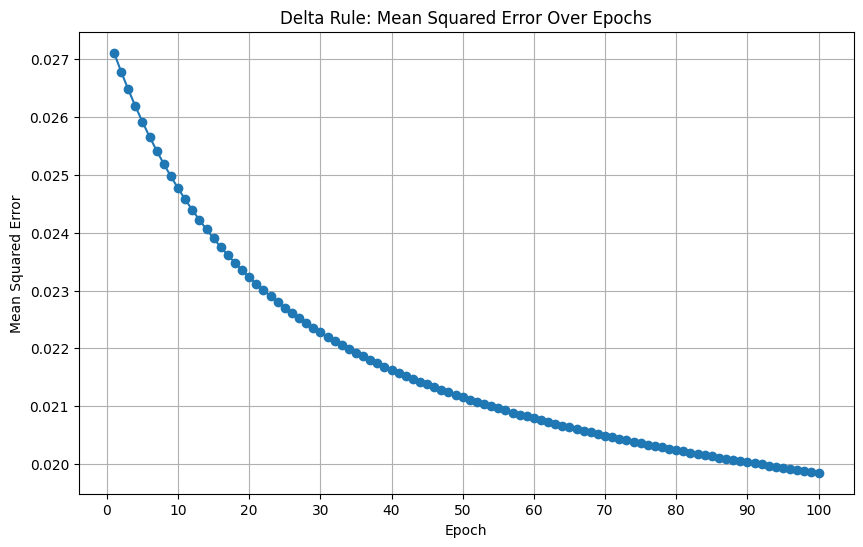

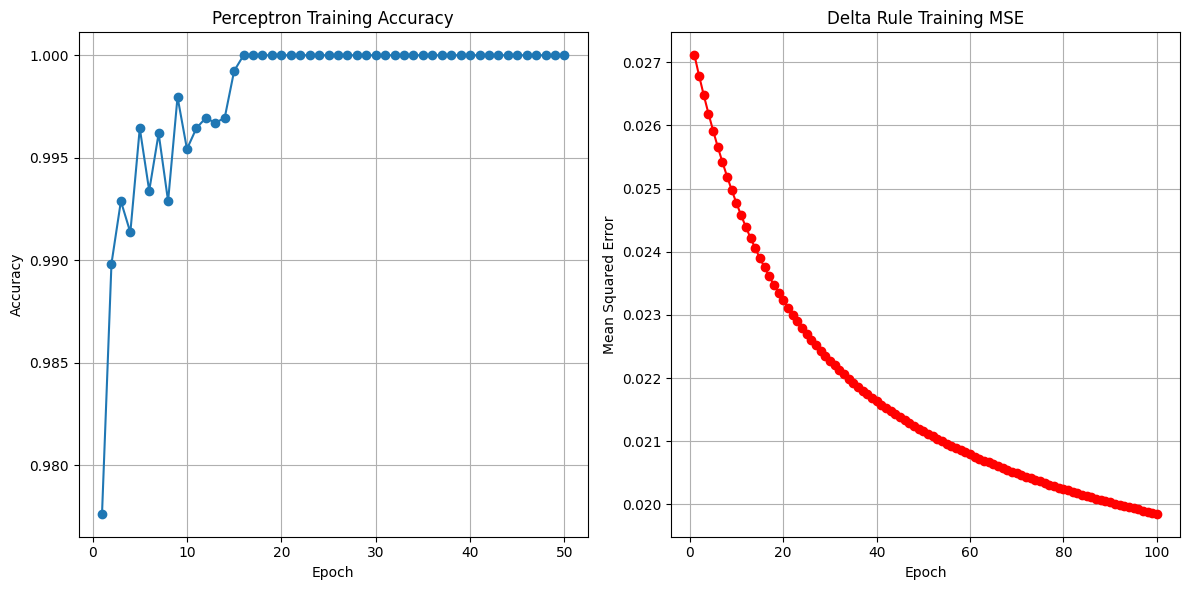

In [31]:
# @title
# 76. Plot the Mean Squared Error over epochs.
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs_delta + 1), mse_history, marker='o', linestyle='-')
plt.title('Delta Rule: Mean Squared Error Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.grid(True)
plt.xticks(np.arange(0, epochs_delta + 1, 10)) # Show ticks every 10 epochs
plt.show()

# 77. Compare the convergence speed of the delta rule to the Perceptron.
# Perceptron training accuracy history is in `accuracy_history`

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(accuracy_history) + 1), accuracy_history, marker='o')
plt.title('Perceptron Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(mse_history) + 1), mse_history, marker='o', color='red')
plt.title('Delta Rule Training MSE')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.grid(True)

plt.tight_layout()
plt.show()
